# Read MS csv

## import

In [1]:
import io
import pandas as pd
import numpy as np
from pathlib import Path
# import re  # for debugging

## read csv

In [10]:
# Read the CSV file
file_path = Path('./20260427v1.csv')  # this should be in the same folder as this script, or provide a complete filepath
assert file_path.is_file(), f"File not found: {file_path}. Please double check the path and filename."
with open(file_path, 'r') as f:
    lines = f.readlines()

# instrument filepath from metadata 
instrument_filepath = lines[0].strip().split(',', 1)[1]  # split on first comma only
print(f"Instrument path: {instrument_filepath}")

Instrument path: D:\MassHunter\Data\ZD\202604\20260421_TigE-v1\QuantResults\20260424.batch.bin


## find sequence and data table lines in the csv

In [11]:
# find sequence and data tables by looking for "Data File" in the table header row
table_starts = []  # (name_line_index, header_line_index, table_name)
for i, line in enumerate(lines):
    if line.strip().startswith('Data File'):
        table_starts.append((i - 1, i, lines[i - 1].strip().strip(',')))  # name row is the line just before

# find table names and print for checking 
table_names = [table_name for _, _, table_name in table_starts]
print(f"Found {len(table_starts)} tables {table_names} at indices:")
max_width = max(len(name) for name in table_names) + 2
for name_idx, header_idx, table_name in table_starts:
    print(f"  {table_name:<{max_width}} : {header_idx}")

Found 4 tables ['Sequence Table', 'Methionine', '5dA', '5 MTA'] at indices:
  Sequence Table   : 4
  Methionine       : 66
  5dA              : 98
  5 MTA            : 130


## parse into dataframes and clean

In [12]:
tables = {}
# parse into however many tables 
for t, (name_idx, header_idx, name) in enumerate(table_starts):
    end_idx = table_starts[t + 1][0] if t + 1 < len(table_starts) else len(lines)  # find last line of each table 
    chunk = ''.join(lines[header_idx:end_idx])  # add the header line in 
    # debugging print statements 
    # print(f"--- {name} ---")
    # print(repr(chunk[:200]))  # show raw first 200 chars including escape characters
    # first_line = chunk.split('\n')[0]
    # print(f"{name}: {repr(first_line)}")
    # print()
    tables[name] = pd.read_csv(io.StringIO(chunk), header=0, skip_blank_lines=True).dropna(how='all')

# make a tables dictionary 
tables = {name: table for name, table in tables.items()}

# show head of each table to check 
for name, table in tables.items():
    print(f"--- {name} (first five rows) ---")
    display(table.head())
    print()
# tables['Sequence Table'].head()

--- Sequence Table (first five rows) ---


,Data File,Name,Type,Vial,Vol.,Level,Acq. Method File
0,01.d,01 water,Blank,NaN,3,NaN,C18_MRM_5dA Met 5MTA_Trp ISTD.m
1,02.d,02 water,Blank,NaN,3,NaN,C18_MRM_5dA Met 5MTA_Trp ISTD.m
2,03.d,03 std 10 1,Cal,NaN,3,1.0,C18_MRM_5dA Met 5MTA_Trp ISTD.m
3,04.d,04 std 25 1,Cal,NaN,3,2.0,C18_MRM_5dA Met 5MTA_Trp ISTD.m
4,05.d,05 std 75 1,Cal,NaN,3,3.0,C18_MRM_5dA Met 5MTA_Trp ISTD.m



--- Methionine (first five rows) ---


,Data File,Type,ISTD,RT,Resp.,ISTD Resp,RR,Final Conc.,Exp. Conc.,Accuracy
0,01.d,Blank,Trp,0.795,21.028,3644.890,0.0058,0.0000,NaN,NaN
1,02.d,Blank,Trp,0.759,90.040,2775.203,0.0324,0.0000,NaN,NaN
2,03.d,Cal,Trp,0.795,642889.220,1974760.087,0.3256,10.5021,10.0,105.0
3,04.d,Cal,Trp,0.795,1048305.285,2326745.368,0.4505,24.3400,25.0,97.4
4,05.d,Cal,Trp,0.795,2058272.653,2027406.198,1.0152,75.1894,75.0,100.3



--- 5dA (first five rows) ---


,Data File,Type,ISTD,RT,Resp.,ISTD Resp,RR,Final Conc.,Exp. Conc.,Accuracy
0,01.d,Blank,Trp,1.002,2.787480e+03,3644.890,0.7648,0.0000,NaN,NaN
1,02.d,Blank,Trp,0.978,2.716952e+03,2775.203,0.9790,0.0000,NaN,NaN
2,03.d,Cal,Trp,1.169,3.985303e+06,1974760.087,2.0181,9.8889,10.0,98.9
3,04.d,Cal,Trp,1.169,6.761780e+06,2326745.368,2.9061,25.7210,25.0,102.9
4,05.d,Cal,Trp,1.181,1.511487e+07,2027406.198,7.4553,73.6943,75.0,98.3



--- 5 MTA (first five rows) ---


,Data File,Type,ISTD,RT,Resp.,ISTD Resp,RR,Final Conc.,Exp. Conc.,Accuracy
0,01.d,Blank,Trp,2.890,1.294414e+03,3644.890,0.3551,0.0000,NaN,NaN
1,02.d,Blank,Trp,2.855,9.474450e+02,2775.203,0.3414,0.0000,NaN,NaN
2,03.d,Cal,Trp,2.831,1.377015e+07,1974760.087,6.9731,10.4726,10.0,104.7
3,04.d,Cal,Trp,2.843,1.853363e+07,2326745.368,7.9655,21.5038,25.0,86.0
4,05.d,Cal,Trp,2.831,3.342181e+07,2027406.198,16.4850,81.7531,75.0,109.0


## rename columns and pivot

In [13]:
# Split sequence and data table names for separate processing
sequence_table_name = table_names[0]
data_table_names = table_names[1:]

# Rename columns in data tables with their table name as prefix
skip_cols = ['Type', 'ISTD']
double_rename = False
for name, table in tables.items():
    if name != sequence_table_name:
        try:
            tables[name] = table.drop(columns=skip_cols)
        except KeyError:
            double_rename = True 
            pass
if double_rename:
    print("Note: you may have doubly renamed your data tables. If you see something like \"Methionine_Methionine_RT\" \n" 
          "in your column names, run the cell \"parse into dataframes and clean\" above and then this cell again.\n")

for table_name in data_table_names:
    tables[table_name].columns = [f'{table_name}_{col}' if col != 'Data File' else 'Data File' for col in tables[table_name].columns]
# to check column renaming: 
# print("Renamed columns in data tables:")
# for table_name in data_table_names:
#     print(f"  {table_name}: {tables[table_name].columns.tolist()}")
# print()

# Merge data tables into the sequence table, matching on the 'Data File' column
final_df = tables[sequence_table_name]
for name in data_table_names:
    final_df = final_df.merge(tables[name], on='Data File', how='left')

# Remove any remaining blank rows
final_df = final_df.dropna(how='all')

# print("Column names:")
# print(final_df.columns.tolist())
print(f"Sequence table rows: {len(tables[sequence_table_name])}")
print(f"Data tables rows: {[len(tables[name]) for name in data_table_names]}")
print(f"Final dataframe shape (rows, cols): {final_df.shape}")
if final_df.shape[0] != len(tables[sequence_table_name]):
    print("Warning: final dataframe row count does not match sequence table row count. Check for merge issues.")
else:
    print("Row count matches sequence table row count, looks good.")
print(f"Target compounds in table: {data_table_names}")
print(f"First few rows:")
display(final_df.head())
# print("Full dataframe:")
# display(final_df)

Sequence table rows: 30
Data tables rows: [30, 30, 30]
Final dataframe shape (rows, cols): (30, 28)
Row count matches sequence table row count, looks good.
Target compounds in table: ['Methionine', '5dA', '5 MTA']
First few rows:


,Data File,Name,Type,Vial,Vol.,Level,Acq. Method File,Methionine_RT,Methionine_Resp.,Methionine_ISTD Resp,...,5dA_Final Conc.,5dA_Exp. Conc.,5dA_Accuracy,5 MTA_RT,5 MTA_Resp.,5 MTA_ISTD Resp,5 MTA_RR,5 MTA_Final Conc.,5 MTA_Exp. Conc.,5 MTA_Accuracy
0,01.d,01 water,Blank,NaN,3,NaN,C18_MRM_5dA Met 5MTA_Trp ISTD.m,0.795,21.028,3644.890,...,0.0000,NaN,NaN,2.890,1.294414e+03,3644.890,0.3551,0.0000,NaN,NaN
1,02.d,02 water,Blank,NaN,3,NaN,C18_MRM_5dA Met 5MTA_Trp ISTD.m,0.759,90.040,2775.203,...,0.0000,NaN,NaN,2.855,9.474450e+02,2775.203,0.3414,0.0000,NaN,NaN
2,03.d,03 std 10 1,Cal,NaN,3,1.0,C18_MRM_5dA Met 5MTA_Trp ISTD.m,0.795,642889.220,1974760.087,...,9.8889,10.0,98.9,2.831,1.377015e+07,1974760.087,6.9731,10.4726,10.0,104.7
3,04.d,04 std 25 1,Cal,NaN,3,2.0,C18_MRM_5dA Met 5MTA_Trp ISTD.m,0.795,1048305.285,2326745.368,...,25.7210,25.0,102.9,2.843,1.853363e+07,2326745.368,7.9655,21.5038,25.0,86.0
4,05.d,05 std 75 1,Cal,NaN,3,3.0,C18_MRM_5dA Met 5MTA_Trp ISTD.m,0.795,2058272.653,2027406.198,...,73.6943,75.0,98.3,2.831,3.342181e+07,2027406.198,16.4850,81.7531,75.0,109.0


# Plot data

## import

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels

## Standard curves

## Data

### set plot title, legend, and colors

Current plot titles:
20260427v1_TigE activity assay_{compound}_{RR or conc}.png
Change "assay_title" in cell above to update

copy+paste dictionaries into cell below and edit

label_map_dict = {
    'all': 'all',
    'noenz': 'noenz',
    'nosam': 'nosam',
    'nosub': 'nosub',
}

Colormap: tab10
color_map_dict = {
    'all': '#1f77b4',
    'noenz': '#ff7f0e',
    'nosam': '#2ca02c',
    'nosub': '#d62728',
}


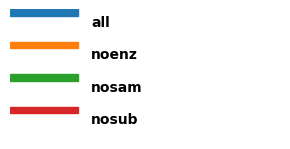

Colormap: Set1
color_map_dict = {
    'all': '#e41a1c',
    'noenz': '#377eb8',
    'nosam': '#4daf4a',
    'nosub': '#984ea3',
}


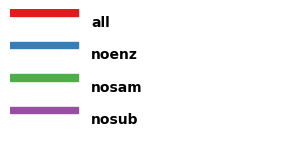

Colormap: Set2
color_map_dict = {
    'all': '#66c2a5',
    'noenz': '#fc8d62',
    'nosam': '#8da0cb',
    'nosub': '#e78ac3',
}


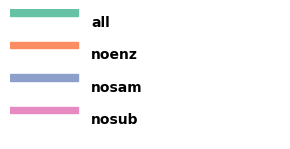

Colormap: Paired
color_map_dict = {
    'all': '#a6cee3',
    'noenz': '#1f78b4',
    'nosam': '#b2df8a',
    'nosub': '#33a02c',
}


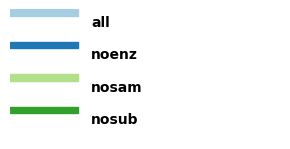

In [15]:
# Filter data for samples (not blanks or calibration standards)
samples_df = final_df[(final_df['Type'] == 'Sample') & (~final_df['Name'].str.contains('water', case=False, na=False))].copy()

# Parse the Name column to extract index, condition, and time
samples_df[['index', 'condition', 'time']] = samples_df['Name'].str.split(expand=True, n=2)
conditions = sorted(samples_df['condition'].dropna().unique())
samples_df['time'] = pd.to_numeric(samples_df['time'], errors='coerce')

# set name for figures
assay_title = "TigE activity assay"
sample_out_png = str(file_path)[:-4].split('/',)[-1] + "_" + assay_title + '_{compound}_{RR or conc}.png'
print(f"Current plot titles:\n{sample_out_png}\nChange \"assay_title\" in cell above to update\n")

print("copy+paste dictionaries into cell below and edit\n")
print("label_map_dict = {")
for cond in conditions:
    print(f"    '{cond}': '{cond}',")
print("}")
print()

possible_colormaps = ['tab10', 'Set1', 'Set2', 'Paired']  # consider tab10, Set1, Set2, Paired
# Display swatches and copyable dict
for color in possible_colormaps:
    cmap = plt.colormaps[color]  
    color_map_dict = {cond: mcolors.to_hex(cmap(i)) for i, cond in enumerate(conditions)}
    print(f"Colormap: {color}")
    print("color_map_dict = {")  # print copyable dict
    for cond, hex_color in color_map_dict.items():
        print(f"    '{cond}': '{hex_color}',")
    print("}")
    color_map_dict = {cond: mcolors.to_hex(cmap(i)) for i, cond in enumerate(conditions)}
    fig, ax = plt.subplots(figsize=(3, len(conditions) * 0.4))
    for i, (cond, hex_color) in enumerate(color_map_dict.items()):
        ax.add_patch(mpatches.Rectangle((0, i), 1, 0.2, color=hex_color))
        ax.text(1.2, i + 0.4, cond, va='center')
    ax.set_xlim(0, 4)
    ax.set_ylim(0, len(conditions))
    ax.axis('off')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

### plot and optionally save

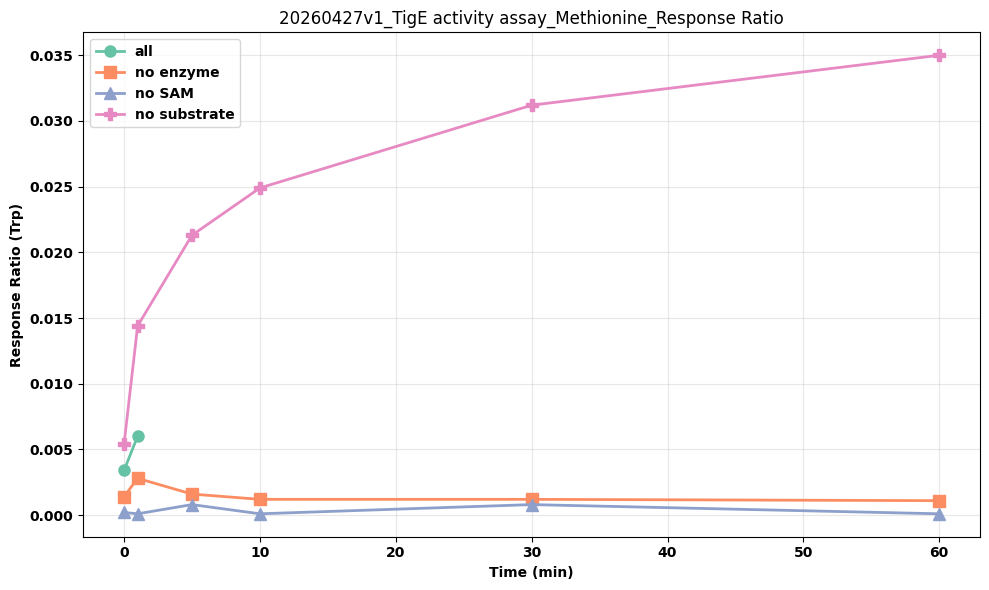

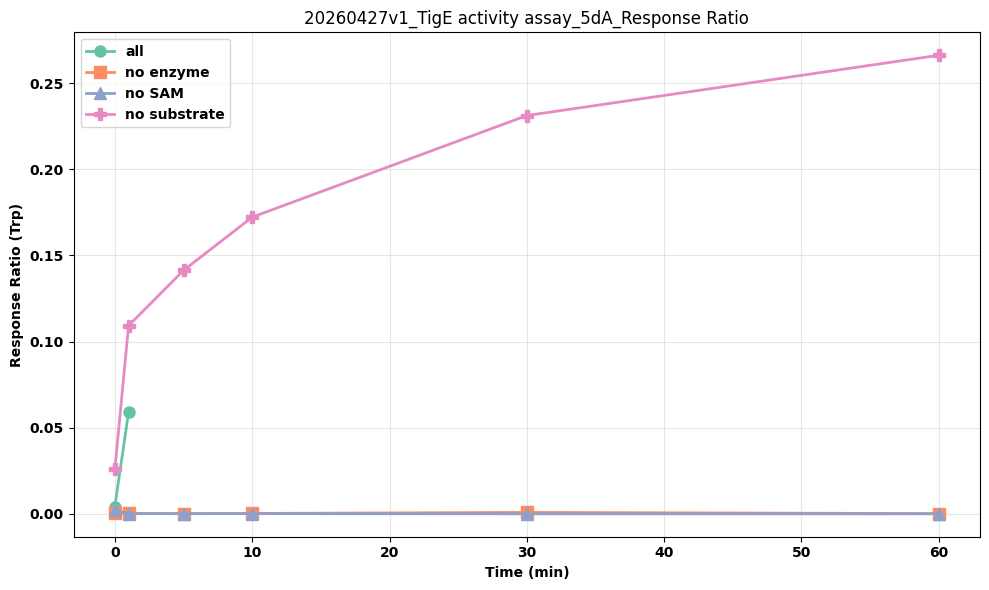

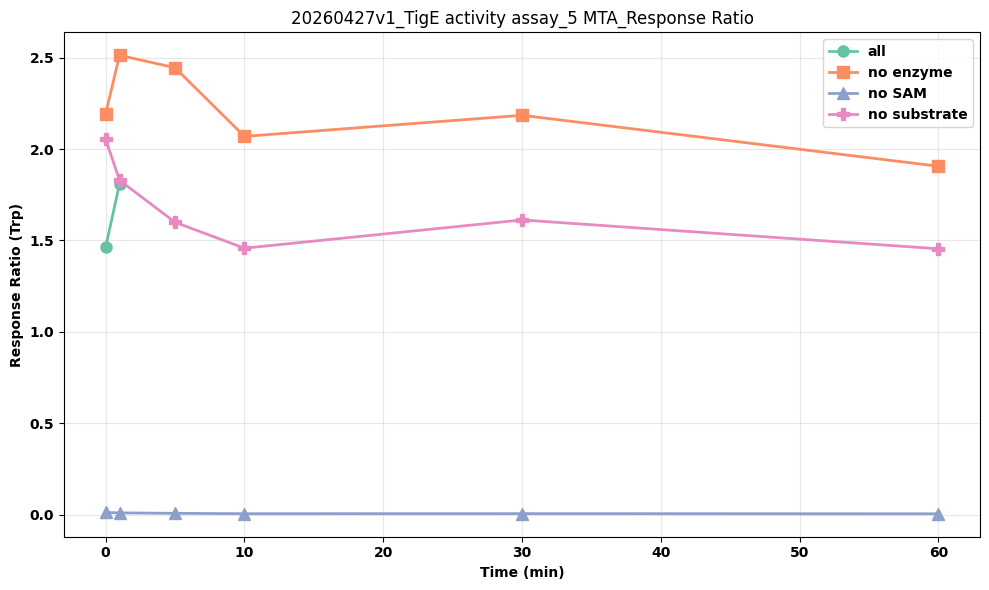

In [16]:
save_plots = True  # set to True once you're ready to save output pngs
plot_RR = True 
plot_conc = False

label_map_dict = {
    'all': 'all',
    'noenz': 'no enzyme',
    'nosam': 'no SAM',
    'nosub': 'no substrate',
}

color_map_dict = {
    'all': '#66c2a5',
    'noenz': '#fc8d62',
    'nosam': '#8da0cb',
    'nosub': '#e78ac3',
}

# o circle, s square, ^ triangle_up, P plus_filled, D diamond, X x_filled, v triangle_down, d thin diamond, * star, h hexagon 
markers = ['o', 's', '^', 'P', 'D', 'X', 'v']  # in the same order as conditions 
marker_dict = {cond: markers[i % len(markers)] for i, cond in enumerate(conditions)}

# Create plots for each compound
for compound in data_table_names:
    rr_col = f'{compound}_RR'
    conc_col = f'{compound}_Final Conc.'
    
    plots = []
    if plot_RR:
        plots.append((rr_col, 'Response Ratio'))
    if plot_conc:
        plots.append((conc_col, 'Concentration'))

    for col, ylabel in plots:
        fig, ax = plt.subplots(figsize=(10, 6))
        for condition in conditions:
            condition_data = samples_df[samples_df['condition'] == condition].sort_values('time')
            ax.plot(
                condition_data['time'],
                condition_data[col],
                marker=marker_dict[condition],
                color=color_map_dict[condition],
                label=label_map_dict[condition],
                linewidth=2,
                markersize=8
            )
        title = f"{file_path.stem}_{assay_title}_{compound}_{ylabel}"
        ax.set_xlabel('Time (min)')
        ax.set_ylabel('Response Ratio (Trp)')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # print(title)
        if save_plots:
            fig.savefig(f"{title}.png", dpi=1500)
        plt.show()